In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [93]:
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
data = pd.read_csv('../datasets/winequalityN.csv')
data.head()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [4]:
data.tail()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
6492,red,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
6493,red,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,NaN,11.2,6
6494,red,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
6495,red,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5
6496,red,6.0,0.310,0.47,3.6,0.067,18.0,42.0,0.99549,3.39,0.66,11.0,6


In [5]:
data.shape

(6497, 13)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6497 non-null   object 
 1   fixed acidity         6487 non-null   float64
 2   volatile acidity      6489 non-null   float64
 3   citric acid           6494 non-null   float64
 4   residual sugar        6495 non-null   float64
 5   chlorides             6495 non-null   float64
 6   free sulfur dioxide   6497 non-null   float64
 7   total sulfur dioxide  6497 non-null   float64
 8   density               6497 non-null   float64
 9   pH                    6488 non-null   float64
 10  sulphates             6493 non-null   float64
 11  alcohol               6497 non-null   float64
 12  quality               6497 non-null   int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [7]:
data.isnull().sum()

type                     0
fixed acidity           10
volatile acidity         8
citric acid              3
residual sugar           2
chlorides                2
free sulfur dioxide      0
total sulfur dioxide     0
density                  0
pH                       9
sulphates                4
alcohol                  0
quality                  0
dtype: int64

In [8]:
data = data.dropna()

In [9]:
data.isnull().sum()

type                    0
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [10]:
data.duplicated().sum()

1168

In [11]:
data = data.drop_duplicates()

In [13]:
data.quality.value_counts(normalize = True)

quality
6    0.436449
5    0.329556
7    0.160907
4    0.038527
8    0.027951
3    0.005666
9    0.000944
Name: proportion, dtype: float64

In [14]:
data.type.value_counts(normalize = True)

type
white    0.744476
red      0.255524
Name: proportion, dtype: float64

In [15]:
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,5295.000000,5295.000000,5295.000000,5295.000000,5295.000000,5295.000000,5295.000000,5295.000000,5295.000000,5295.000000,5295.000000,5295.000000
mean,7.218008,0.344021,0.318782,5.051029,0.056690,30.046837,114.118225,0.994536,3.224385,0.533199,10.550154,5.796034
std,1.320690,0.168237,0.147112,4.500641,0.036901,17.827151,56.787187,0.002969,0.160155,0.149851,1.186533,0.880005
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.240000,1.800000,0.038000,16.000000,74.000000,0.992200,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.300000,0.310000,2.700000,0.047000,28.000000,116.000000,0.994670,3.210000,0.510000,10.400000,6.000000
75%,7.700000,0.410000,0.400000,7.500000,0.066000,41.000000,154.000000,0.996780,3.330000,0.600000,11.400000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


<Axes: xlabel='type', ylabel='count'>

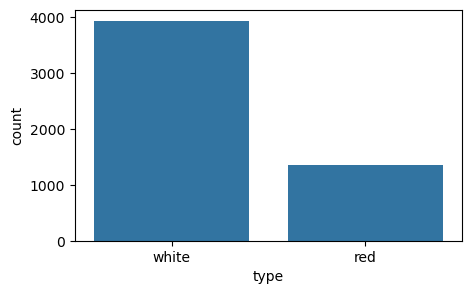

In [16]:
plt.figure(figsize=(5 , 3))
sns.countplot(x= 'type', data=data)

<Axes: >

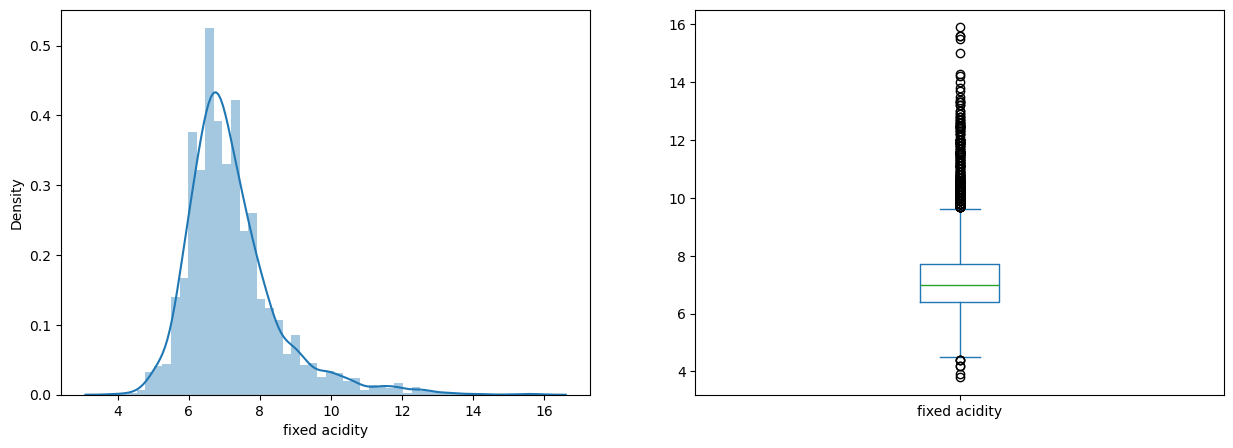

In [17]:
plt.figure(2)
plt.subplot(121)
sns.distplot(data['fixed acidity'])
plt.subplot(122)
data['fixed acidity'].plot.box(figsize=(15, 5))

<Axes: >

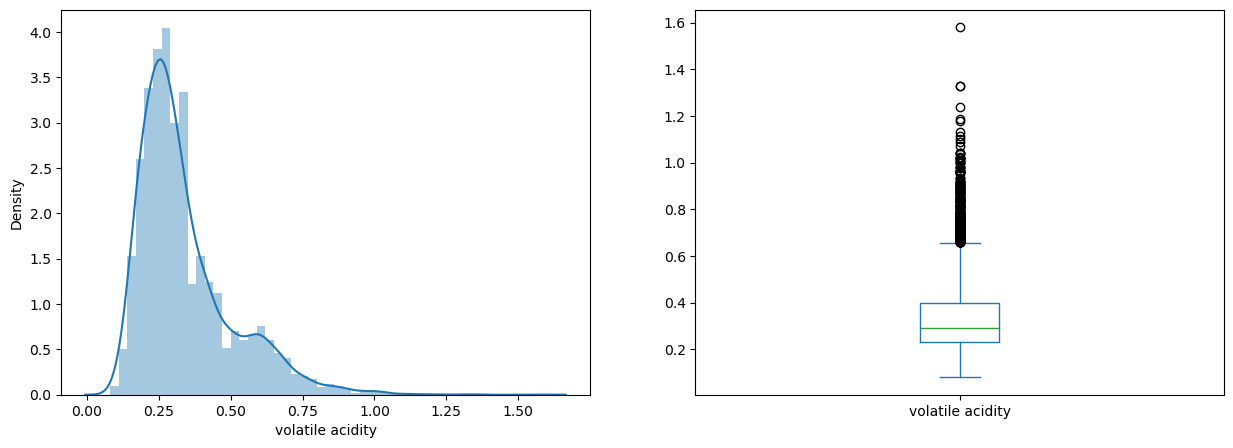

In [24]:
plt.figure(2)
plt.subplot(121)
sns.distplot(data['volatile acidity'])
plt.subplot(122)
data['volatile acidity'].plot.box(figsize=(15, 5))

<Axes: xlabel='quality', ylabel='fixed acidity'>

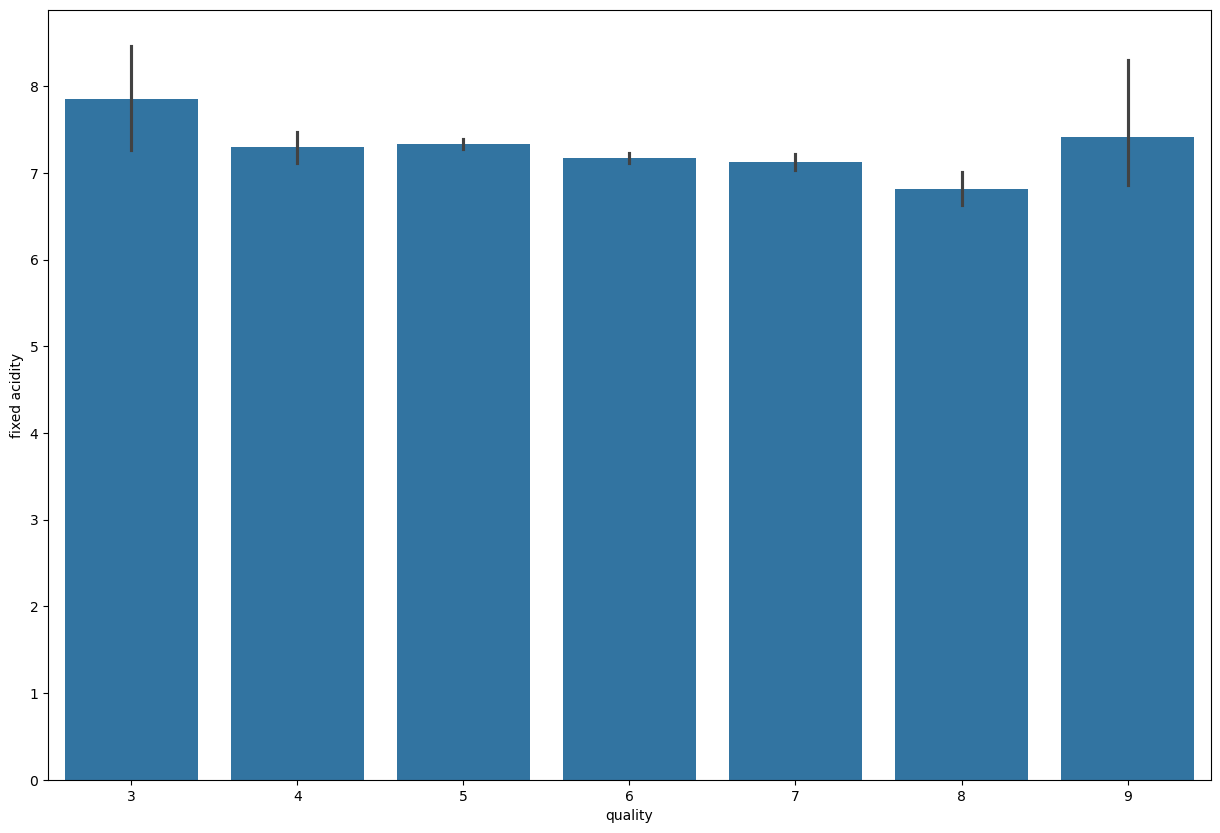

In [50]:
plt.figure(figsize=(15, 10))
sns.barplot(x='quality', y='fixed acidity', data = data)

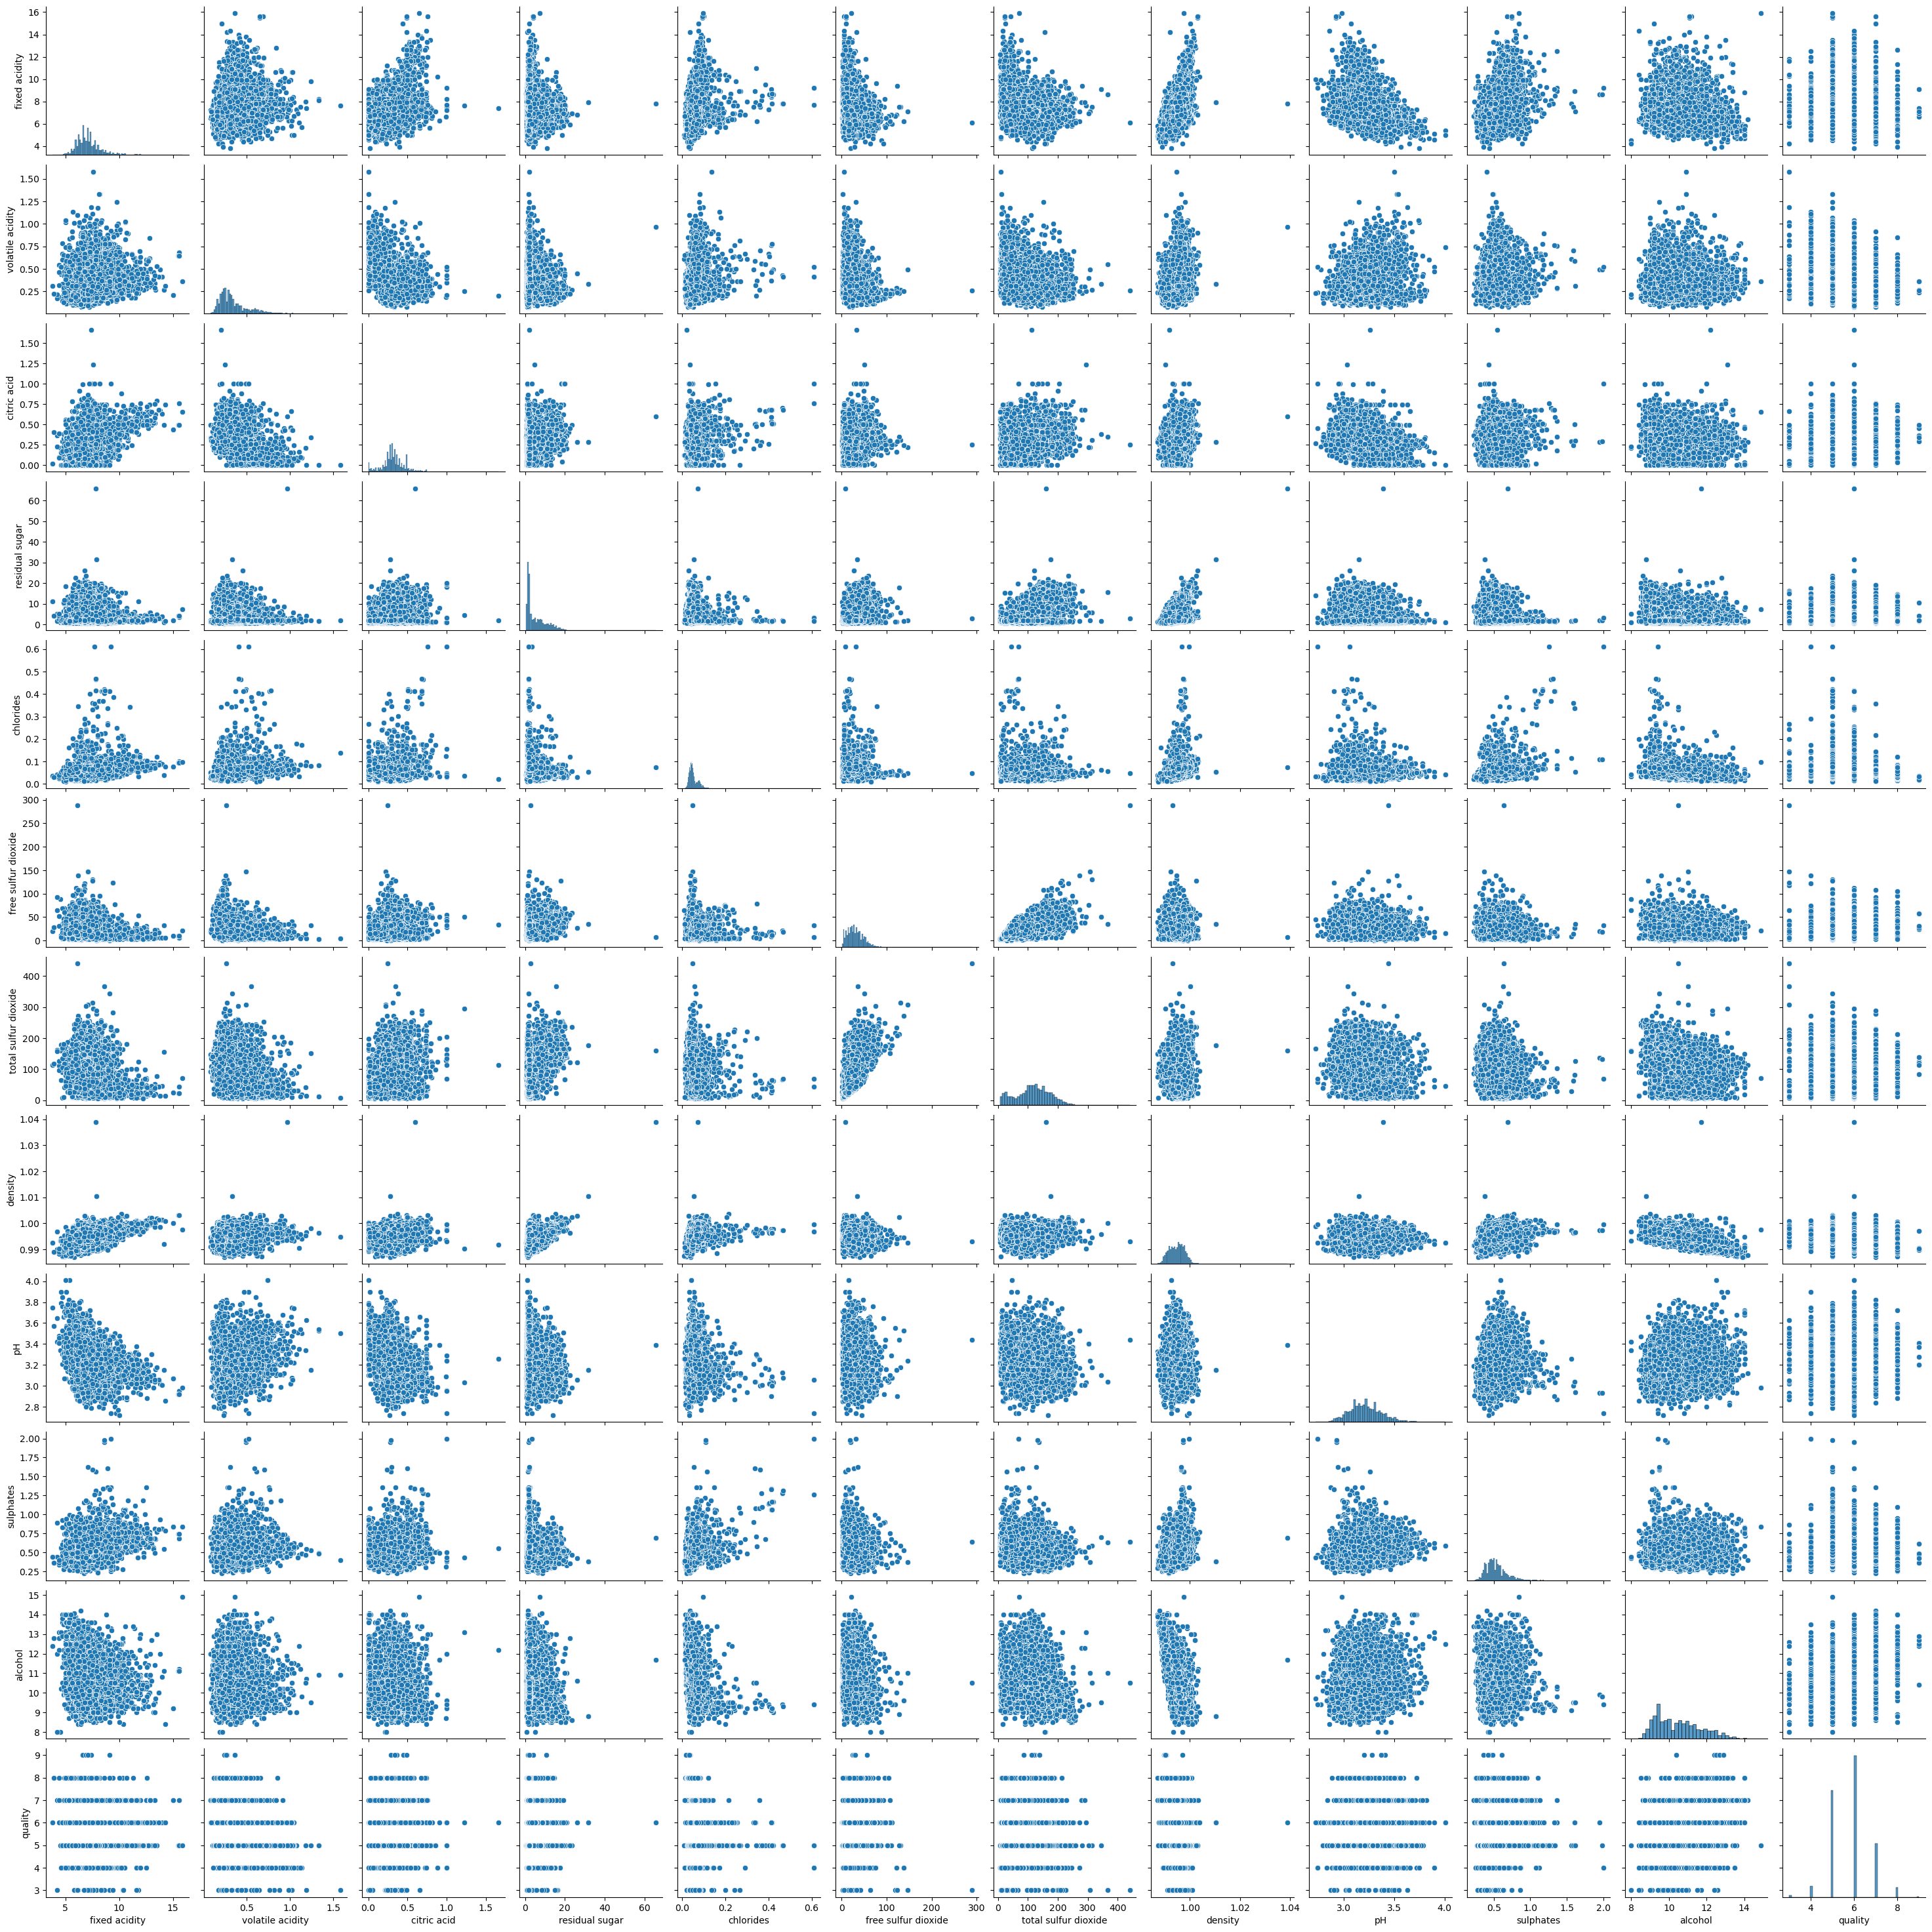

In [26]:
sns.pairplot(data)

In [57]:
df= data.drop(columns = ['type'])

# Correlations 

In [58]:
df.corr()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,0.216524,0.329252,-0.106084,0.289903,-0.282025,-0.328631,0.478920,-0.269624,0.307044,-0.103657,-0.079599
volatile acidity,0.216524,1.000000,-0.382750,-0.164438,0.368266,-0.349784,-0.401231,0.308416,0.245329,0.226537,-0.066781,-0.265214
citric acid,0.329252,-0.382750,1.000000,0.146528,0.055266,0.130802,0.194231,0.095824,-0.342648,0.062121,-0.005124,0.097926
residual sugar,-0.106084,-0.164438,0.146528,1.000000,-0.123115,0.399579,0.487534,0.520194,-0.233319,-0.174663,-0.305311,-0.054625
chlorides,0.289903,0.368266,0.055266,-0.123115,1.000000,-0.187312,-0.270009,0.372126,0.025963,0.405771,-0.270196,-0.202016
free sulfur dioxide,-0.282025,-0.349784,0.130802,0.399579,-0.187312,1.000000,0.721308,0.005827,-0.141368,-0.199005,-0.169854,0.053786
total sulfur dioxide,-0.328631,-0.401231,0.194231,0.487534,-0.270009,0.721308,1.000000,0.005974,-0.222003,-0.275389,-0.247779,-0.050728
density,0.478920,0.308416,0.095824,0.520194,0.372126,0.005827,0.005974,1.000000,0.034979,0.283042,-0.668950,-0.325338
pH,-0.269624,0.245329,-0.342648,-0.233319,0.025963,-0.141368,-0.222003,0.034979,1.000000,0.166139,0.096615,0.038903
sulphates,0.307044,0.226537,0.062121,-0.174663,0.405771,-0.199005,-0.275389,0.283042,0.166139,1.000000,-0.019008,0.041806


<Axes: >

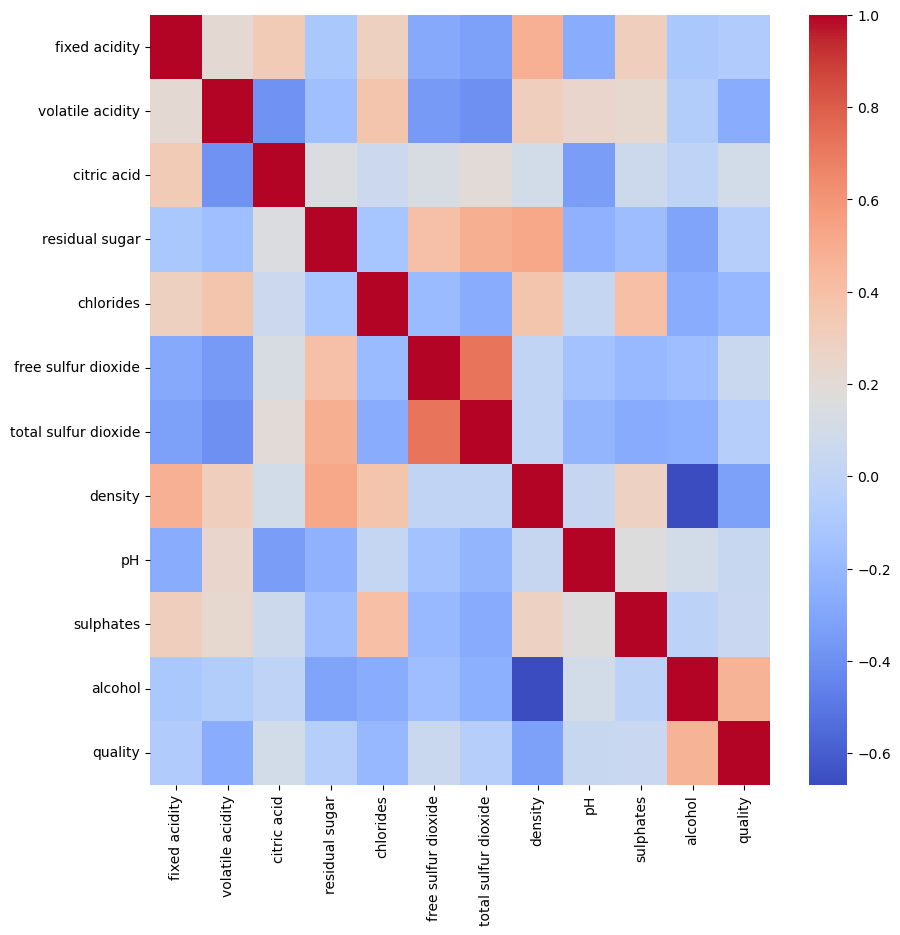

In [62]:
plt.figure(figsize=(10, 10))
sns.heatmap(df.corr(), cmap='coolwarm')

We can see some of columns have the most correlation like 'free sulfur dioxide' and 'total sulfur dioxide'. Also 'alcohol' and 'density' have the strong negative correlation. 

The very high correlation tends to influence the model, so we basically remove them.

Here we remove 'total sulfur dioxide' which is in the correlation of '0.721308' with 'free sulfur dioxide'.

In [63]:
wine = data.drop('total sulfur dioxide', axis = 1)

In [64]:
wine.head()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,0.9956,3.19,0.40,9.9,6
6,white,6.2,0.32,0.16,7.0,0.045,30.0,0.9949,3.18,0.47,9.6,6


# Get Dummies

In [65]:
wine_ml = pd.get_dummies(wine, drop_first=True)

In [66]:
wine_ml.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,density,pH,sulphates,alcohol,quality,type_white
0,7.0,0.27,0.36,20.7,0.045,45.0,1.0010,3.00,0.45,8.8,6,True
1,6.3,0.30,0.34,1.6,0.049,14.0,0.9940,3.30,0.49,9.5,6,True
2,8.1,0.28,0.40,6.9,0.050,30.0,0.9951,3.26,0.44,10.1,6,True
3,7.2,0.23,0.32,8.5,0.058,47.0,0.9956,3.19,0.40,9.9,6,True
6,6.2,0.32,0.16,7.0,0.045,30.0,0.9949,3.18,0.47,9.6,6,True


In [67]:
wine_ml.isnull().sum()

fixed acidity          0
volatile acidity       0
citric acid            0
residual sugar         0
chlorides              0
free sulfur dioxide    0
density                0
pH                     0
sulphates              0
alcohol                0
quality                0
type_white             0
dtype: int64

In [68]:
Q = wine_ml['quality'].apply(lambda q: 1 if q>=7 else 0)

In [84]:
y = Q
y

0       0
1       0
2       0
3       0
6       0
       ..
6490    0
6491    0
6492    0
6495    0
6496    0
Name: quality, Length: 5295, dtype: int64

In [72]:
x = wine_ml.drop('quality', axis=1)

In [80]:
scaler = StandardScaler()
scaler.fit(x)
x_scaled = scaler.transform(x)

In [83]:
x_scaled

array([[-0.16508655, -0.4400209 ,  0.28020842, ..., -0.55526714,
        -1.47515354,  0.5858556 ],
       [-0.69516261, -0.26168411,  0.14424475, ..., -0.28830936,
        -0.88514391,  0.5858556 ],
       [ 0.66789012, -0.38057531,  0.55213577, ..., -0.62200659,
        -0.37942137,  0.5858556 ],
       ...,
       [-0.77088777,  1.52168375, -1.62328301, ...,  0.31234565,
        -0.04227301, -1.70690524],
       [-0.99806322,  1.78918893, -1.35135566, ...,  1.17995844,
        -0.29513428, -1.70690524],
       [-0.92233807, -0.20223852,  1.02800863, ...,  0.84626121,
         0.37916244, -1.70690524]])

In [85]:
x = x_scaled

In [86]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state = 245)

Logistic Regression Classifier

In [89]:
logreg= LogisticRegression()

In [90]:
logreg.fit(x_train, y_train)

LogisticRegression()

In [95]:
y_pred = logreg.predict(x_test)

In [96]:
accuracy_score(y_test, y_pred)

0.9697828139754485

In [98]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1027
           1       0.00      0.00      0.00        32

    accuracy                           0.97      1059
   macro avg       0.48      0.50      0.49      1059
weighted avg       0.94      0.97      0.95      1059



In [100]:
print(confusion_matrix(y_test, y_pred))

[[1027    0]
 [  32    0]]


# Random Forest Classifier

In [101]:
from sklearn.ensemble import RandomForestClassifier

In [102]:
rfc = RandomForestClassifier()

In [103]:
rfc.fit(x_train, y_train)

RandomForestClassifier()

In [104]:
rfc_pred = rfc.predict(x_test)

In [106]:
accuracy_score(y_test, rfc_pred)

0.9688385269121813

## important featrues

In [107]:
rfc.feature_importances_

array([0.09172307, 0.09902479, 0.08006324, 0.10835945, 0.09361176,
       0.10846233, 0.11661902, 0.09065021, 0.09514707, 0.11305711,
       0.00328196])

<Axes: >

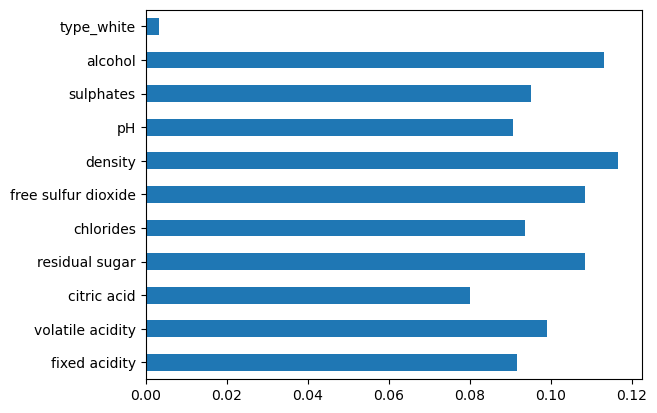

In [108]:
pd.Series(rfc.feature_importances_, index = wine_ml.drop('quality', axis=1).columns).plot(kind='barh') 

## Test Model

In [173]:
pred_test = wine.iloc[2]
pred_test 

type                    white
fixed acidity             8.1
volatile acidity         0.28
citric acid               0.4
residual sugar            6.9
chlorides                0.05
free sulfur dioxide      30.0
density                0.9951
pH                       3.26
sulphates                0.44
alcohol                  10.1
quality                     6
Name: 2, dtype: object

In [174]:
pred_test['type'] = 1
pred_test.drop('quality', inplace=True)

In [175]:
pred_test

type                        1
fixed acidity             8.1
volatile acidity         0.28
citric acid               0.4
residual sugar            6.9
chlorides                0.05
free sulfur dioxide      30.0
density                0.9951
pH                       3.26
sulphates                0.44
alcohol                  10.1
Name: 2, dtype: object

In [176]:
pred_test = np.asarray(pred_test).reshape(1, -1)
scaler.fit(pred_test)

StandardScaler()

In [177]:
pred_test_scal= scaler.transform(pred_test)

In [178]:
y_pred_test_logreg = logreg.predict(pred_test_scal)

In [179]:
y_pred_test_logreg

array([0], dtype=int64)

In [180]:
if y_pred_test_logreg == 0:
    print('This is not a good quality!')
elif y_pred_test_logreg == 1:
    print('Such a good quality!')
else:
    print('Something went wrong!')

This is not a good quality!


In [182]:
rfc_test_pred = rfc.predict(pred_test_scal)

In [183]:
rfc_test_pred

array([0], dtype=int64)